
# Decision-based Attacks (BoundaryAttack) on scikit-learn models — ART Example Notebook

This notebook trains several scikit-learn models and demonstrates running the **Boundary Attack** (decision-based) from the **Adversarial Robustness Toolbox (ART)** against them.

**Models included:** LogisticRegression, MLPClassifier (scikit-learn's neural net), SVC, RandomForestClassifier, XGBClassifier (xgboost sklearn API).

**Notes**
- Boundary Attack is a decision-based attack: it requires only label queries (`predict(X)`). No gradients or probabilities needed.
- This notebook uses ART's `SklearnClassifier` wrapper where possible. If your ART version or environment differs, consult ART docs.
- If you don't have `CSVs/newDataset.csv`, the notebook will generate a synthetic dataset for demonstration.
- Install required packages in the first cell if needed.


In [1]:

# Install required packages (uncomment if needed). Internet access required.
# !pip install adversarial-robustness-toolbox scikit-learn xgboost pandas numpy


In [2]:

import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
from pathlib import Path

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import accuracy_score, classification_report

from sklearn.linear_model import LogisticRegression
from sklearn.neural_network import MLPClassifier
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier

# XGBoost scikit-learn API
try:
    from xgboost import XGBClassifier
    has_xgb = True
except Exception as e:
    XGBClassifier = None
    has_xgb = False

# ART imports
from art.attacks.evasion import BoundaryAttack
from art.estimators.classification import SklearnClassifier





## 1) Configuration

- `DATA_PATH` — path to CSV file with features and a label column. If not present, the notebook will create a synthetic dataset.
- `LABEL_COL` — name of the label column in your CSV (default `label`).
- We'll scale features to [0, 1] for consistent clipping during attacks (BoundaryAttack itself works with raw inputs but ART wrappers require clip_values).


In [7]:
# Configuration: set DATA_PATH as a string (change this to your CSV path)
# Make DATA_PATH a plain string so it's easy to set programmatically or from the UI.
DATA_PATH = 'C:/Users/Jan/Git/AnomalyDetection/CSVs/newDataset.csv'   # <-- change this string to your CSV path, e.g. 'C:/data/myfile.csv'
LABEL_COL = 'anomaly'
TEST_SIZE = 0.8
RANDOM_STATE = 100

# Convert to Path where needed elsewhere in the notebook
from pathlib import Path as _Path
DATA_PATH_OBJ = _Path(DATA_PATH)

CLIP_VALUES = (0.0, 1.0)  # We'll scale features to this range for ART wrappers

# Limit how many test samples to attack for speed
N_ATTACK = 200


import numpy as np

def art_probs_to_labels(probs):
    """
    Convert ART / sklearn predict outputs to 1D label array.
    - Binary cases:
       * If shape (N,2) -> take argmax or probs[:,1] >= 0.5
       * If shape (N,1) or (N,) -> threshold at 0.5
    - Multi-class: argmax over last axis
    Returns dtype int.
    """
    probs = np.asarray(probs)
    if probs.ndim == 1:
        return (probs >= 0.5).astype(int)
    if probs.ndim == 2:
        if probs.shape[1] == 1:
            return (probs.ravel() >= 0.5).astype(int)
        else:
            # multi-class or binary given as two-column probs
            # choose argmax (for binary this picks class with higher prob)
            return np.argmax(probs, axis=1).astype(int)
    raise ValueError(f"Unexpected prediction shape: {probs.shape}")





## 2) Load data

Expectations: all features numeric. If using your own CSV with categorical data, preprocess accordingly before running attacks.


In [8]:

from sklearn.datasets import make_classification

df = pd.read_csv(DATA_PATH_OBJ)
assert LABEL_COL in df.columns, f"Label column '{LABEL_COL}' not found in CSV: {df.columns.tolist()}"
y = df[LABEL_COL].values
X = df.drop(columns=[LABEL_COL]).values
print(f"Loaded CSV: {DATA_PATH_OBJ} -> X: {X.shape}, y: {y.shape}")


Loaded CSV: C:\Users\Jan\Git\AnomalyDetection\CSVs\newDataset.csv -> X: (2123, 22), y: (2123,)



## 3) Train/test split & scaling

We scale features into `[0, 1]`. This is recommended for ART wrappers using `clip_values`.


In [9]:

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=TEST_SIZE,
                                                    stratify=y, random_state=RANDOM_STATE)

scaler = MinMaxScaler(feature_range=CLIP_VALUES)
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

print('Shapes:', X_train_sc.shape, X_test_sc.shape)


Shapes: (424, 22) (1699, 22)



## 4) Model training

Train a standard set of scikit-learn classifiers. These are quick defaults — replace with your tuned models as needed.


In [ ]:

models = {}

# Logistic Regression
lr = LogisticRegression(max_iter=200, class_weight='balanced', random_state=RANDOM_STATE)
lr.fit(X_train_sc, y_train)
models['LogisticRegression'] = lr

# MLP (scikit-learn Neural Net)
mlp = MLPClassifier(hidden_layer_sizes=(128,64), max_iter=200, random_state=RANDOM_STATE)
mlp.fit(X_train_sc, y_train)
models['MLPClassifier'] = mlp

# SVM — we set probability=True to keep options open, but BoundaryAttack only needs predict()
svm = SVC(probability=True, kernel='rbf', random_state=RANDOM_STATE)
svm.fit(X_train_sc, y_train)
models['SVC'] = svm

# Random Forest
rf = RandomForestClassifier(n_estimators=200, random_state=RANDOM_STATE)
rf.fit(X_train_sc, y_train)
models['RandomForest'] = rf

# XGBoost (if available)
if has_xgb:
    xgb = XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=RANDOM_STATE)
    xgb.fit(X_train_sc, y_train)
    models['XGBClassifier'] = xgb
else:
    print('[WARN] xgboost not installed; skipping XGBClassifier.')

In [11]:

# Baseline evaluation on the full test set
for name, m in models.items():
    # some sklearn models use predict_proba, some don't — we use predict()
    y_pred = m.predict(X_test_sc)
    print(f"{name}: test accuracy = {accuracy_score(y_test, y_pred):.4f}")


LogisticRegression: test accuracy = 0.8988
MLPClassifier: test accuracy = 0.9447
SVC: test accuracy = 0.8917
RandomForest: test accuracy = 0.9441
XGBClassifier: test accuracy = 0.9441



## 5) Wrap each model with ART's `SklearnClassifier`

BoundaryAttack is decision-based and works with label queries. We wrap the scikit-learn models
with `SklearnClassifier` (this wrapper will call `predict_proba` if available, but BoundaryAttack
itself only requires labels).


In [12]:

art_classifiers = {}
for name, m in models.items():
    try:
        # SklearnClassifier expects the model and clip_values. Some wrappers also accept `nb_classes`.
        clf = SklearnClassifier(model=m, clip_values=CLIP_VALUES)
        art_classifiers[name] = clf
    except Exception as e:
        print(f"Failed to wrap {name} with SklearnClassifier: {e}")


Failed to wrap XGBClassifier with SklearnClassifier: Model is not an sklearn model. Received '<class 'xgboost.sklearn.XGBClassifier'>'



## 6) Run Boundary Attack (decision-based) against each model

We will attack a subset `N_ATTACK` of test samples for speed. BoundaryAttack starts from a **starting adversarial example** for each sample — ART's implementation will create a starting point automatically (random) but the attack may be slow. For faster experiments reduce `N_ATTACK`.


In [14]:

results = {}

# Select subset to attack
n_attack = min(N_ATTACK, X_test_sc.shape[0])
X_eval = X_test_sc[:n_attack]
y_eval = y_test[:n_attack]

for name, clf in art_classifiers.items():
    print('\n' + '='*60)
    print('Attacking model:', name)
    try:
        attack = BoundaryAttack(
            estimator=clf,
            targeted=False,        # <- important
            max_iter=2000,
            delta=0.01,
            epsilon=1e-6
            )
        X_adv = attack.generate(x=X_eval)  # <- no y

        
        # Clean
        y_pred_clean_probs = clf.predict(X_eval)
        y_pred_clean = art_probs_to_labels(y_pred_clean_probs)
        
        # Adversarial
        y_pred_adv_probs = clf.predict(X_adv)
        y_pred_adv = art_probs_to_labels(y_pred_adv_probs)
        
        acc_clean = accuracy_score(y_eval, y_pred_clean)
        acc_adv   = accuracy_score(y_eval, y_pred_adv)
        print(f"Clean acc: {acc_clean:.4f} | Adv acc: {acc_adv:.4f}")
        print(classification_report(y_eval, y_pred_adv, digits=4))

        results[name] = dict(clean_acc=acc_clean, adv_acc=acc_adv)
    except Exception as e:
        print(f"Attack failed for {name}: {e}")



Attacking model: LogisticRegression


Boundary attack: 100%|██████████| 200/200 [05:00<00:00,  1.50s/it]


Clean acc: 0.8850 | Adv acc: 0.1250
              precision    recall  f1-score   support

           0     0.2683    0.0705    0.1117       156
           1     0.0881    0.3182    0.1379        44

    accuracy                         0.1250       200
   macro avg     0.1782    0.1943    0.1248       200
weighted avg     0.2286    0.1250    0.1175       200


Attacking model: MLPClassifier


Boundary attack: 100%|██████████| 200/200 [04:30<00:00,  1.35s/it]


Clean acc: 0.9650 | Adv acc: 0.1900
              precision    recall  f1-score   support

           0     0.0000    0.0000    0.0000       156
           1     0.1959    0.8636    0.3193        44

    accuracy                         0.1900       200
   macro avg     0.0979    0.4318    0.1597       200
weighted avg     0.0431    0.1900    0.0703       200


Attacking model: SVC


Boundary attack: 100%|██████████| 200/200 [1:01:31<00:00, 18.46s/it]


Clean acc: 0.9050 | Adv acc: 0.2150
              precision    recall  f1-score   support

           0     0.0000    0.0000    0.0000       156
           1     0.2161    0.9773    0.3539        44

    accuracy                         0.2150       200
   macro avg     0.1080    0.4886    0.1770       200
weighted avg     0.0475    0.2150    0.0779       200


Attacking model: RandomForest


Boundary attack:  34%|███▎      | 67/200 [18:41<37:06, 16.74s/it]


KeyboardInterrupt: 


## 7) Save results and example adversarial samples

The notebook saves a small CSV with original vs adversarial predictions for the attacked subset.


In [ ]:
OUT_DIR = Path('Results/BoundaryAttack')
OUT_DIR.mkdir(parents=True, exist_ok=True)

records = []
for name, clf in art_classifiers.items():
    try:
        print(f"Processing {name} ...")
        attack = BoundaryAttack(estimator=clf, max_iter=2000, delta=0.01, epsilon=1e-6)
        X_adv = attack.generate(x=X_eval, y=y_eval)   # note: for untargeted you can omit y
        # Convert predictions (may be probs) to labels
        y_pred_clean_raw = clf.predict(X_eval)
        y_pred_adv_raw   = clf.predict(X_adv)

        y_pred_clean = art_probs_to_labels(y_pred_clean_raw)
        y_pred_adv   = art_probs_to_labels(y_pred_adv_raw)

        # Prepare saved DataFrame (inverse scale back to original feature values)
        X_adv_inv   = scaler.inverse_transform(X_adv)
        X_clean_inv = scaler.inverse_transform(X_eval)

        df_out = pd.DataFrame(X_clean_inv, columns=[f'f{i}' for i in range(X_clean_inv.shape[1])])
        df_out['label_true'] = np.asarray(y_eval).astype(int)
        df_out['pred_clean']  = y_pred_clean
        df_out['pred_adv']    = y_pred_adv

        save_path = OUT_DIR / f"{name}_adv_examples.csv"
        df_out.to_csv(save_path, index=False)
        print(f"Saved adversarial examples for {name} to: {save_path}")
    except Exception as e:
        print(f"Could not save adversarial examples for {name}: {e}")


Boundary attack: 100%|██████████| 200/200 [00:56<00:00,  3.53it/s]

Saved adversarial examples for RandomForest to: Results\BoundaryAttack\RandomForest_adv_examples.csv


<Figure size 640x480 with 0 Axes>

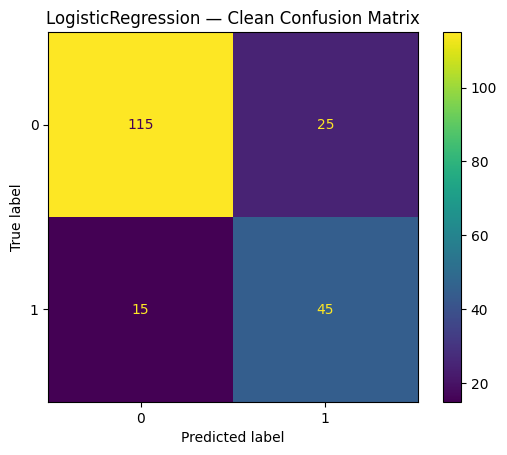

<Figure size 640x480 with 0 Axes>

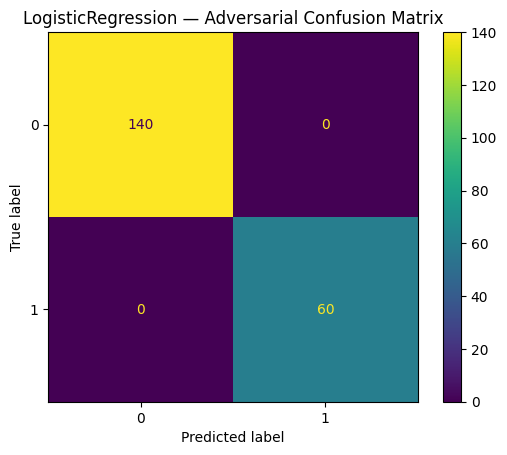

In [ ]:
import pandas as pd
import numpy as np
from pathlib import Path
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt

OUT_DIR = Path("Results/BoundaryAttack")

# Load all per-model CSVs
summaries = []
per_model_frames = {}
for csv in OUT_DIR.glob("*_adv_examples.csv"):
    name = csv.stem.replace("_adv_examples","")
    df = pd.read_csv(csv)
    per_model_frames[name] = df
    acc_clean = accuracy_score(df["label_true"], df["pred_clean"])
    acc_adv   = accuracy_score(df["label_true"], df["pred_adv"])
    flip_rate = (df["pred_clean"] != df["pred_adv"]).mean()
    summaries.append({"model": name, "clean_acc": acc_clean, "adv_acc": acc_adv, "flip_rate": flip_rate})

summary_df = pd.DataFrame(summaries).sort_values("adv_acc", ascending=False).reset_index(drop=True)
summary_df

#Confusion Matrices

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

MODEL = summary_df["model"].iloc[0]  # pick one, e.g., 'LogisticRegression'
df = per_model_frames[MODEL]
y = df["label_true"].to_numpy()

# Clean
cm_clean = confusion_matrix(y, df["pred_clean"])
disp = ConfusionMatrixDisplay(cm_clean)
plt.figure()
disp.plot(values_format="d")
plt.title(f"{MODEL} — Clean Confusion Matrix")
plt.show()

# Adversarial
cm_adv = confusion_matrix(y, df["pred_adv"])
disp = ConfusionMatrixDisplay(cm_adv)
plt.figure()
disp.plot(values_format="d")
plt.title(f"{MODEL} — Adversarial Confusion Matrix")
plt.show()



## Notes, tips & troubleshooting

- BoundaryAttack can be slow — reduce `N_ATTACK` or `max_iter` to speed up experiments.
- If an attack fails with shape or label errors, check ART and scikit-learn versions. ART's API can vary between releases; consult the ART docs for your installed version.
- Ensure numeric features; for categorical inputs use appropriate encodings (one-hot/ordinal) and understand whether perturbations make sense for your data domain.
- For repeatability experiment with different `delta`, `max_iter`, and starting points.
